In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # change file name if needed
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.columns = df.columns.str.strip()

In [5]:
df.replace(" ", np.nan, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [6]:
# Convert target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
# Convert remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [12]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [13]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))

In [14]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_svm, "SVM")


 Logistic Regression
Accuracy: 0.8126330731014905
Precision: 0.6379746835443038
Recall: 0.675603217158177

 KNN
Accuracy: 0.7750177430801988
Precision: 0.6186440677966102
Recall: 0.3914209115281501

 SVM
Accuracy: 0.7352732434350603
Precision: 0.0
Recall: 0.0


C:\Users\indra\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
y_prob_lr = lr.predict_proba(X_test)[:,1]
print("ROC-AUC (LR):", roc_auc_score(y_test, y_prob_lr))

ROC-AUC (LR): 0.8558567184572548


In [16]:
feature_importance = pd.Series(lr.coef_[0], index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

InternetService_Fiber optic       0.528486
PaymentMethod_Electronic check    0.453505
PaperlessBilling_Yes              0.283894
MonthlyCharges                    0.225282
SeniorCitizen                     0.216255
customerID_0607-DAAHE             0.172295
customerID_6323-AYBRX             0.172257
customerID_6532-YLWSI             0.169371
customerID_1043-YCUTE             0.168241
customerID_3512-IZIKN             0.167523
dtype: float64


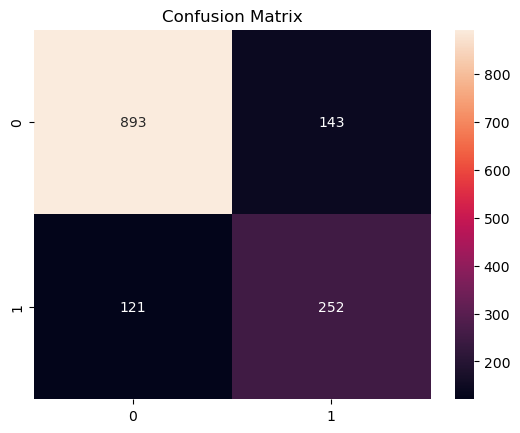

In [17]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()